# Econ 372 — Homework

Renee Ngai

In [2]:
import pandas as pd
import numpy as np

# The data lives in the data/ folder at the top of the repo. From this
df = pd.read_csv(r"C:\Users\ngair\Downloads\nj_ihc_family_premiums_2000_2008.csv")

In [3]:
df.head()

,Year,Horizon_BCBSNJ_PlanD_1000Ded_Family_MonthlyPremium,Aetna_PlanD_1000Ded_Family_MonthlyPremium,Celtic_PlanC_2500Ded_Family_MonthlyPremium,IHC_TotalYearEnd_Standard_Enrollment
0,2000,1676.90,2949.0,2551.0,98769
1,2001,2072.39,4312.0,3188.0,84968
2,2002,2765.07,4266.0,4003.0,78698
3,2003,3573.71,4266.0,7843.0,75839
4,2004,4437.96,4390.0,7843.0,75047


## Question 1

Write your code and your answer here.

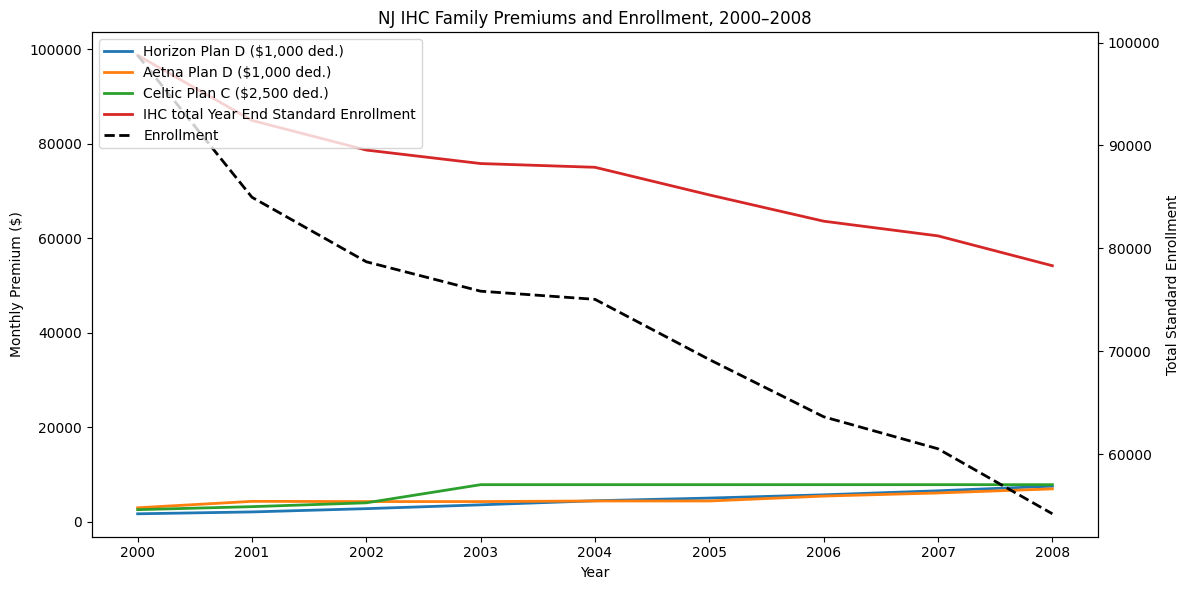

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(df["Year"], df["Horizon_BCBSNJ_PlanD_1000Ded_Family_MonthlyPremium"], label="Horizon Plan D ($1,000 ded.)", linewidth=2)
plt.plot(df["Year"], df["Aetna_PlanD_1000Ded_Family_MonthlyPremium"], label="Aetna Plan D ($1,000 ded.)", linewidth=2)
plt.plot(df["Year"], df["Celtic_PlanC_2500Ded_Family_MonthlyPremium"], label="Celtic Plan C ($2,500 ded.)", linewidth=2)
plt.plot(df["Year"], df["IHC_TotalYearEnd_Standard_Enrollment"], label="IHC total Year End Standard Enrollment", linewidth=2)

# Plot enrollment on secondary axis
ax1 = plt.gca()
ax2 = ax1.twinx()
ax2.plot(df["Year"], df["IHC_TotalYearEnd_Standard_Enrollment"], label="Enrollment", color="black", linestyle="--", linewidth=2)

# #Don't add different enrollemnt, just average them 

# Labels and formatting
ax1.set_xlabel("Year")
ax1.set_ylabel("Monthly Premium ($)")
ax2.set_ylabel("Total Standard Enrollment")

ax1.set_title("NJ IHC Family Premiums and Enrollment, 2000–2008")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()


b. Description: The graphs shows NJ IHC Family Premiums and Enrollment from the year 2000-2008. The graph shows that IHC total year end standard enrollment and total enrollment shows a steady decline from 2000-2008. On the other hand, Aetna Plan D, horizon Plan D, and Celtic Plan C shows a slight increasing trend from 2000-2008.

c. This graph is an evidence of adverse selection because as the insurance premiums rise, households who are healthy switch to chaper alternatives, and the pool worsens to only sicker populations, causing the insurance premiums to rise again. Therefore, insurance premium increases occur hand in hand with declining enrollment.

d. My verdict is that this might not be a death spiral, becasue medical cost inflation, regulatory changes, as well as macroeconomic situations could also explain these patterns. Weighing against the adverse selection explanation, this is a death spiral as shown by the data that IHC total year end standard enrollment decreaes as the monthly premium from the insurance plan increases, this creates an endless spiral of increasingp remiums and healthier families leaving the plan, causing a worsening risk pool.

## Question 2

Write your code and your answer here.

In [15]:
ma = pd.read_csv(r"C:\Users\ngair\Downloads\medicare-ma-penetration.csv")
ffs = pd.read_csv(r"C:\Users\ngair\Downloads\medicare-ffs-costs.csv")

In [16]:
ma.head()

,fips,state,county,year,total_eligibles,ma_enrolled
0,1001,AL,AUTAUGA,2008,7589,2057.0
1,1001,AL,AUTAUGA,2009,7870,2363.0
2,1001,AL,AUTAUGA,2010,8167,2195.0
3,1001,AL,AUTAUGA,2011,8509,2386.0
4,1001,AL,AUTAUGA,2012,8969,2652.0


In [17]:
ffs.head()

,fips,state,county,year,ffs_enrollment,ffs_spending
0,1001,AL,AUTAUGA,2008,4214.0,33123019.0
1,1001,AL,AUTAUGA,2009,4125.0,30547571.0
2,1001,AL,AUTAUGA,2010,4504.0,33213585.0
3,1001,AL,AUTAUGA,2011,4648.0,36147956.0
4,1001,AL,AUTAUGA,2012,4751.0,35987007.0


In [19]:
df_merged = pd.merge(
    ma,
    ffs,
    on=["county", "year"],
    how="inner"
)

df_merged.head()

,fips_x,state_x,county,year,total_eligibles,ma_enrolled,fips_y,state_y,ffs_enrollment,ffs_spending
0,1001,AL,AUTAUGA,2008,7589,2057.0,1001,AL,4214.0,33123019.0
1,1001,AL,AUTAUGA,2009,7870,2363.0,1001,AL,4125.0,30547571.0
2,1001,AL,AUTAUGA,2010,8167,2195.0,1001,AL,4504.0,33213585.0
3,1001,AL,AUTAUGA,2011,8509,2386.0,1001,AL,4648.0,36147956.0
4,1001,AL,AUTAUGA,2012,8969,2652.0,1001,AL,4751.0,35987007.0


In [21]:
national = (
    df_merged.groupby("year")
    .agg({
        "ma_enrolled": "sum",
        "total_eligibles": "sum",
        "ffs_spending": "sum",
        "ffs_enrollment": "sum"
    })
    .reset_index()
)

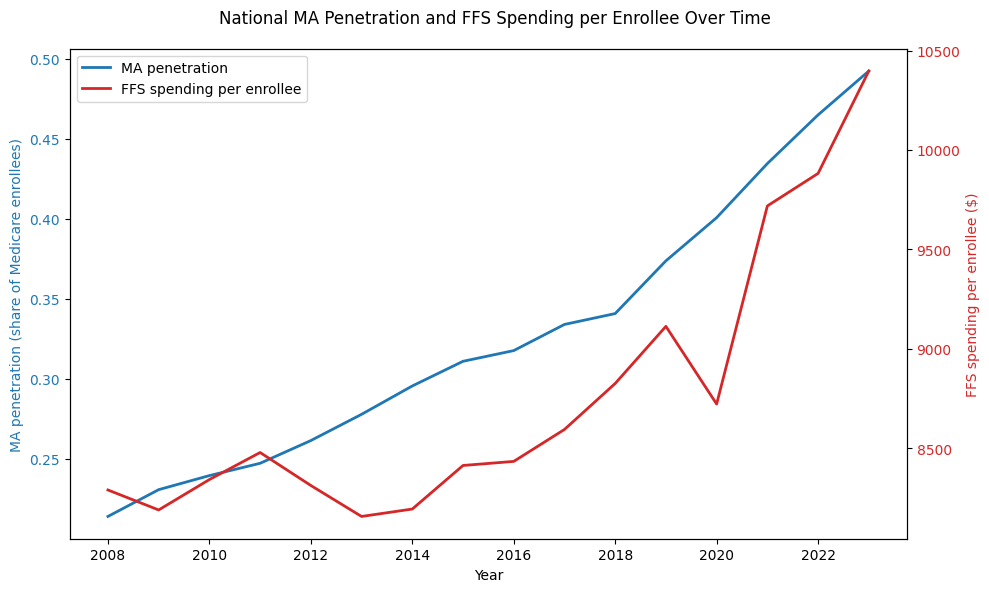

In [22]:
# National MA penetration:
#   ma_penetration = sum(ma_enrollees) / sum(total_medicare_enrollees)
national["ma_penetration"] = (
    national["ma_enrolled"] / national["total_eligibles"]
)

# National FFS spending per enrollee:
#   ffs_spending_per_enrollee = sum(ffs_spending_total) / sum(ffs_enrollees)
national["ffs_spending_per_enrollee"] = (
    national["ffs_spending"] / national["ffs_enrollment"]
)

# 4. Plot both series over time
fig, ax1 = plt.subplots(figsize=(10, 6))

# MA penetration on left axis
ax1.plot(
    national["year"],
    national["ma_penetration"],
    color="tab:blue",
    linewidth=2,
    label="MA penetration"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("MA penetration (share of Medicare enrollees)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# FFS spending per enrollee on right axis
ax2 = ax1.twinx()
ax2.plot(
    national["year"],
    national["ffs_spending_per_enrollee"],
    color="tab:red",
    linewidth=2,
    label="FFS spending per enrollee"
)
ax2.set_ylabel("FFS spending per enrollee ($)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Title and combined legend
fig.suptitle("National MA Penetration and FFS Spending per Enrollee Over Time")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

fig.tight_layout()
plt.show()


b. Describe the trends: the graph shows that MA penetration and FFS spending per enrollee is increasing from the year 2008-2022 at the same time. From 2013-2024 and 2019-2022, FFS spending per enrollee showed a small decline but MA penetration continues to increase at a steady rate. 

c. (3 points) Risk adjustment. What is risk adjustment, as we covered it in class, and what problem does it aim to address in the Medicare Advantage market?

Risk adjustment isadjusting payments and insurance premiums based on health status and expected costs. It aims to address the sicker population with more expensive medical costs in the medicare Advantage Market by calculating a risk adjustment score for everyone enrollled in the Medicare advantage program instead of having each Medicare advantage enrollee paying the same fee.

d. (3 points) Beyond risk adjustment. Risk adjustment is not the only tool to combat adverse selection. Find one other policy that has been used or proposed to limit selection in Medicare Advantage, or to hold down fee-for-service costs, cite the source where you read about it, and explain in a few sentences how it would help. Use a credible health-policy source such as KFF, the Commonwealth Fund, Health Affairs, or a MedPAC report, not a general website or blog.


Another policy that has been proposed to limit selection in Medicare Advantage is the CMS Medicare Advantage and Section 1876 Cost Plan Network Adequacy Guidance, which requires Medicare Advantage plans to meet minimum provider and facility availability standards across specialties. This limits adverse selection becasue it prevents a health only network desgin and ensures access for patients with higher medical needs.

Source: https://www.cms.gov/files/document/medicare-advantage-and-section-1876-cost-plan-network-adequacy-guidance-12-09-2024.pdf?utm_source=copilot.com